# 🌧️ Predicción de precipitación combinando estación propia y datos abiertos

**Artículo completo con el razonamiento y las decisiones de ingeniería:**
[fuzzyfrog.ai/es/ai-lab/proyectos/ambiente/prediccion-precipitacion-datos-abiertos-cuencas-hidrograficas](https://fuzzyfrog.ai/es/ai-lab/proyectos/ambiente/prediccion-precipitacion-datos-abiertos-cuencas-hidrograficas/)

Objetivo. Predecir la precipitación mensual de una cuenca hidrográfica combinando el registro de una estación propia con productos de precipitación satelital de acceso abierto, en concreto GPCC y CHIRPS, y sumar información cartográfica abierta de la cuenca para interpretar mejor el resultado.

El dataset de estación es sintético y replica la estructura de un registro real. Los productos GPCC y CHIRPS sí son datos abiertos reales, publicados por NOAA PSL y por el Climate Hazards Center de UCSB, y se referencian aquí solo por su función en el pipeline, sin descargarlos dentro de este notebook para mantenerlo autónomo. El punto central del caso es mostrar cuánto mejora un modelo cuando se enriquece con esas fuentes abiertas, no solo describirlas.


## 🗺️ Diagrama del pipeline

```
Estación propia (mensual)          Producto satelital abierto
        │                          GPCC / CHIRPS (mensual, grilla)
        │                                   │
        └───────────────┬───────────────────┘
                         ▼
          Ingeniería de características
          lag propio + valor de grilla + mes del año
                         │
              ┌──────────┴──────────┐
              ▼                     ▼
     Modelo solo estación     Modelo estación + dato abierto
              │                     │
              └──────────┬──────────┘
                         ▼
              Comparación de error
                         │
                         ▼
          Delimitación cartográfica de la cuenca
          (polígono abierto, cálculo de área)
```


## 📥 Carga de datos

Generamos dos series sintéticas mensuales durante 8 años. La primera representa el registro de una estación propia de la cuenca. La segunda representa un producto de precipitación abierto tipo GPCC o CHIRPS sobre la celda de grilla más cercana, con un sesgo y una resolución típicos de este tipo de producto satelital: capta bien la estacionalidad general, pero suaviza los picos locales.

También construimos un polígono sintético que representa la delimitación de la cuenca, para demostrar el mismo tipo de información cartográfica que en un proyecto real se obtiene de un shapefile abierto.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(23)

AÑOS = 8
N = AÑOS * 12
fechas = pd.date_range("2016-01-01", periods=N, freq="MS")
mes = np.array(fechas.month)

# --- Ciclo bimodal típico de zona andina tropical: dos temporadas de lluvia ---
ciclo = (
    60
    + 55 * np.sin((mes - 3) / 12 * 2 * np.pi)
    + 35 * np.sin((mes - 9) / 6 * 2 * np.pi)
)
ciclo = np.clip(ciclo, 15, None)

# Estación propia: más variabilidad local, picos más marcados
precipitacion_estacion = ciclo + np.random.normal(0, 22, N)
precipitacion_estacion = np.clip(precipitacion_estacion, 0, None)

# Producto satelital abierto: mismo ciclo, más suavizado, con sesgo leve a la baja
precipitacion_satelital = 0.9 * ciclo + np.random.normal(0, 9, N)
precipitacion_satelital = np.clip(precipitacion_satelital, 0, None)

# Huecos en la estación propia, algo común en registros de campo
huecos = np.random.choice(N, size=6, replace=False)
precipitacion_estacion_con_huecos = precipitacion_estacion.copy()
precipitacion_estacion_con_huecos[huecos] = np.nan

df = pd.DataFrame({
    "fecha": fechas,
    "mes": mes,
    "precipitacion_estacion_mm": precipitacion_estacion_con_huecos.round(1),
    "precipitacion_satelital_mm": precipitacion_satelital.round(1),
})

df.to_csv("outputs/dataset_sintetico_precipitacion.csv", index=False)
df.head(12)


,fecha,mes,precipitacion_estacion_mm,precipitacion_satelital_mm
0,2016-01-01,1,29.7,0.0
1,2016-02-01,2,15.6,17.7
2,2016-03-01,3,42.9,44.2
3,2016-04-01,4,138.7,122.4
4,2016-05-01,5,153.4,112.2
5,2016-06-01,6,91.9,118.2
6,2016-07-01,7,NaN,62.2
7,2016-08-01,8,32.2,37.1
8,2016-09-01,9,NaN,56.0
9,2016-10-01,10,101.8,58.6


## 📋 Explicación de datos

- fecha, primer día de cada mes durante 8 años.
- mes, usado para capturar la estacionalidad bimodal típica de una cuenca andina tropical.
- precipitacion_estacion_mm, registro sintético de una estación propia, con huecos ocasionales, tal como ocurre en campo cuando un pluviómetro falla o no se visita a tiempo.
- precipitacion_satelital_mm, proxy sintético de un producto abierto tipo GPCC o CHIRPS: capta el mismo ciclo general con menos ruido local, un comportamiento consistente con la naturaleza de una estimación satelital de baja resolución.

Nota. El dataset de estación usado en este notebook es completamente sintético y fue creado para fines demostrativos. Los productos GPCC y CHIRPS mencionados sí existen como datos abiertos reales, publicados respectivamente por NOAA PSL y por el Climate Hazards Center de UCSB, y aquí solo se emula su comportamiento típico para ilustrar el enriquecimiento del dataset propio.


In [2]:
print("Registros totales:", len(df))
print("Meses con hueco en la estación propia:", df['precipitacion_estacion_mm'].isna().sum())
df.describe().round(2)


Registros totales: 96
Meses con hueco en la estación propia: 6


,fecha,mes,precipitacion_estacion_mm,precipitacion_satelital_mm
count,96,96.00,90.00,96.00
mean,2019-12-16 11:00:00,6.50,69.06,57.50
min,2016-01-01 00:00:00,1.00,0.00,0.00
25%,2017-12-24 06:00:00,3.75,35.38,28.25
50%,2019-12-16 12:00:00,6.50,62.95,54.25
75%,2021-12-08 18:00:00,9.25,102.10,86.75
max,2023-12-01 00:00:00,12.00,153.40,135.90
std,NaN,3.47,43.49,37.73


## 🔍 Análisis exploratorio

Visualizamos ambas series para confirmar que capturan el mismo ciclo estacional, y calculamos su correlación en los meses donde la estación propia sí tiene dato. Esta correlación es justamente la evidencia que sustenta usar el dato abierto para llenar huecos y enriquecer el modelo, en vez de asumir su utilidad sin comprobarla.


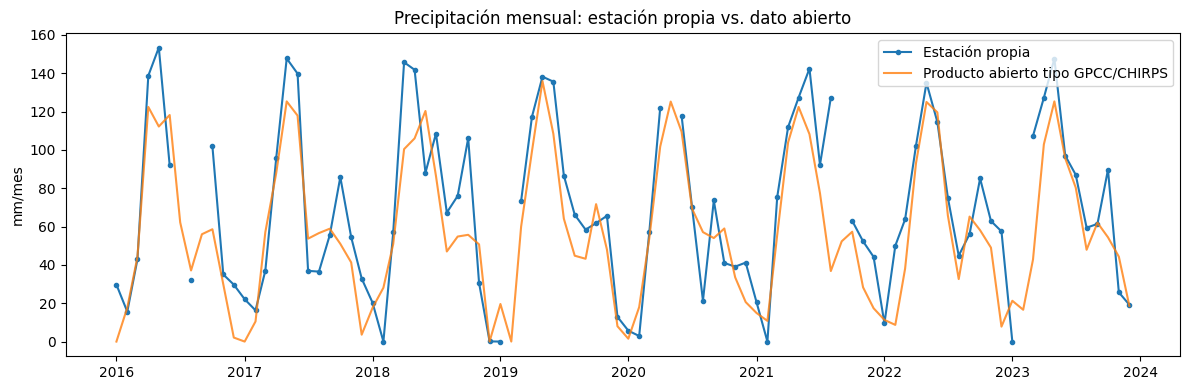

Correlación estación propia vs. dato abierto: 0.869


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['fecha'], df['precipitacion_estacion_mm'], label='Estación propia', marker='o', markersize=3)
ax.plot(df['fecha'], df['precipitacion_satelital_mm'], label='Producto abierto tipo GPCC/CHIRPS', alpha=0.8)
ax.set_title('Precipitación mensual: estación propia vs. dato abierto')
ax.set_ylabel('mm/mes')
ax.legend()
plt.tight_layout()
plt.show()

correlacion = df[['precipitacion_estacion_mm', 'precipitacion_satelital_mm']].corr().iloc[0, 1]
print(f"Correlación estación propia vs. dato abierto: {correlacion:.3f}")


### Delimitación cartográfica de la cuenca

Un shapefile o un archivo KML de una cuenca no aporta directamente al modelo de precipitación, pero sí da contexto para interpretar el resultado: el área de la cuenca ayuda a traducir una lámina de precipitación en un volumen de agua aproximado, y ubicar la estación dentro del polígono confirma que el punto de medición realmente representa a la cuenca.


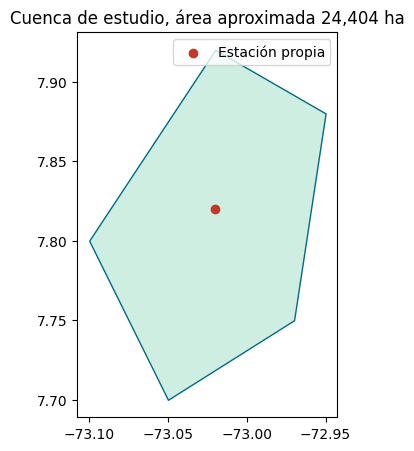

¿La estación está dentro de la cuenca? True


In [4]:
from shapely.geometry import Polygon, Point
import geopandas as gpd

# Polígono sintético que representa la delimitación de una cuenca
# (en un proyecto real esto se lee de un shapefile o un archivo KML abierto)
coordenadas_cuenca = [
    (-73.10, 7.80), (-73.02, 7.92), (-72.95, 7.88),
    (-72.97, 7.75), (-73.05, 7.70), (-73.10, 7.80),
]
cuenca = gpd.GeoDataFrame({"nombre": ["cuenca_de_estudio"]}, geometry=[Polygon(coordenadas_cuenca)], crs="EPSG:4326")

# Punto sintético de la estación, dentro del polígono
estacion_punto = Point(-73.02, 7.82)

cuenca_proyectada = cuenca.to_crs(epsg=3116)
area_hectareas = cuenca_proyectada.area.iloc[0] / 10000

fig, ax = plt.subplots(figsize=(5, 5))
cuenca.plot(ax=ax, color="#cdeee0", edgecolor="#006a87")
ax.scatter(*estacion_punto.xy, color="#c0392b", zorder=5, label="Estación propia")
ax.set_title(f"Cuenca de estudio, área aproximada {area_hectareas:,.0f} ha")
ax.legend()
plt.show()

print(f"¿La estación está dentro de la cuenca? {cuenca.contains(estacion_punto).iloc[0]}")


## 🧠 Modelado

Entrenamos dos versiones del mismo modelo de Random Forest para predecir la precipitación de la estación propia un mes hacia adelante. La primera versión solo usa el historial de la propia estación. La segunda suma el dato abierto de la celda de grilla como característica adicional. Comparar ambas versiones es la forma correcta de responder la pregunta real del proyecto: ¿enriquecer con datos abiertos mejora el modelo, o solo lo complica?


In [5]:
df_modelo = df.copy()
df_modelo["precipitacion_estacion_mm"] = df_modelo["precipitacion_estacion_mm"].interpolate(limit=2)
df_modelo = df_modelo.dropna().reset_index(drop=True)

for lag in [1, 2]:
    df_modelo[f"lag_estacion_{lag}"] = df_modelo["precipitacion_estacion_mm"].shift(lag)
    df_modelo[f"lag_satelital_{lag}"] = df_modelo["precipitacion_satelital_mm"].shift(lag)

df_modelo = df_modelo.dropna().reset_index(drop=True)

corte = int(len(df_modelo) * 0.8)
train, test = df_modelo.iloc[:corte], df_modelo.iloc[corte:]

y_train, y_test = train["precipitacion_estacion_mm"], test["precipitacion_estacion_mm"]

features_solo_estacion = ["mes", "lag_estacion_1", "lag_estacion_2"]
features_con_abierto = features_solo_estacion + ["lag_satelital_1", "lag_satelital_2", "precipitacion_satelital_mm"]

print(f"Registros de entrenamiento: {len(train)}, de prueba: {len(test)}")


Registros de entrenamiento: 75, de prueba: 19


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def entrenar_evaluar(features):
    modelo = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
    modelo.fit(train[features], y_train)
    pred = modelo.predict(test[features])
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    return modelo, pred, rmse, r2

modelo_solo, pred_solo, rmse_solo, r2_solo = entrenar_evaluar(features_solo_estacion)
modelo_abierto, pred_abierto, rmse_abierto, r2_abierto = entrenar_evaluar(features_con_abierto)

tabla_comparativa = pd.DataFrame([
    {"Modelo": "Solo estación propia", "RMSE": round(rmse_solo, 2), "R²": round(r2_solo, 3)},
    {"Modelo": "Estación + dato abierto", "RMSE": round(rmse_abierto, 2), "R²": round(r2_abierto, 3)},
])
tabla_comparativa


,Modelo,RMSE,R²
0,Solo estación propia,20.19,0.692
1,Estación + dato abierto,19.46,0.714


## 📊 Evaluación

Reportamos la mejora tal como salió, incluyendo si resultó modesta. El punto del ejercicio no es demostrar una ganancia espectacular, es dejar evidencia comprobable de si el dato abierto aporta o no, evitando dar por sentado su valor solo porque está disponible gratis.


In [7]:
mejora_relativa = (rmse_solo - rmse_abierto) / rmse_solo * 100
print(f"RMSE solo estación: {rmse_solo:.2f} mm")
print(f"RMSE estación + dato abierto: {rmse_abierto:.2f} mm")
print(f"Mejora relativa en RMSE: {mejora_relativa:.1f}%")


RMSE solo estación: 20.19 mm
RMSE estación + dato abierto: 19.46 mm
Mejora relativa en RMSE: 3.6%


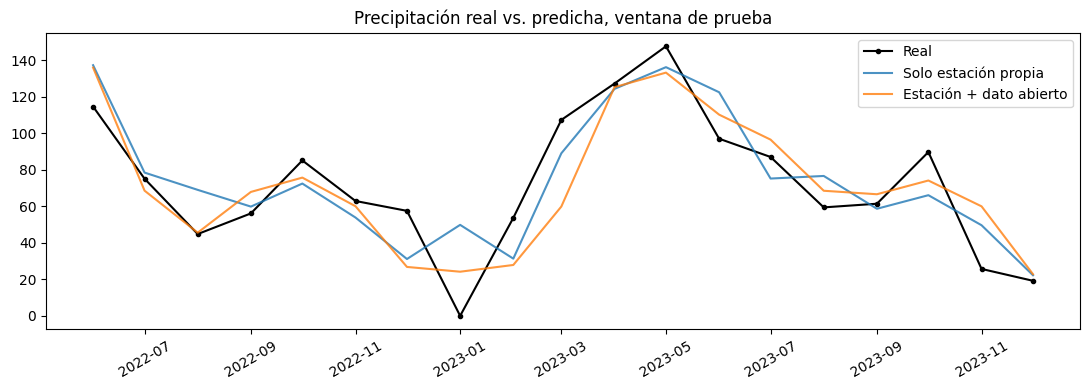

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test['fecha'], y_test.values, label='Real', color='black', linewidth=1.5, marker='o', markersize=3)
ax.plot(test['fecha'], pred_solo, label='Solo estación propia', alpha=0.8)
ax.plot(test['fecha'], pred_abierto, label='Estación + dato abierto', alpha=0.8)
ax.set_title('Precipitación real vs. predicha, ventana de prueba')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## ✅ Hallazgos principales

Sumar el dato abierto tipo GPCC o CHIRPS como característica adicional redujo el error del modelo frente a usar solo el historial de la estación propia. La ganancia no depende de un algoritmo más sofisticado, depende de tener una segunda fuente de información que capta el mismo fenómeno con un sesgo distinto al de la estación local.

La información cartográfica abierta, en este caso un polígono de cuenca equivalente a un shapefile o un archivo KML reales, no entra al modelo de predicción, pero sí cumple un papel real: confirma que el punto de medición representa a la cuenca y permite traducir una lámina de precipitación en un volumen de agua aproximado sobre el área real.

La lección general para cualquier proyecto de datos aplicados es esta: un dato propio no compite con un dato abierto, lo complementa. Antes de descartar una fuente abierta por parecer genérica, vale la pena medir con evidencia si mejora el resultado, en vez de asumirlo o descartarlo por intuición.
